<a href="https://colab.research.google.com/github/suparuek2405/credit-default-dl/blob/main/notebooks/03_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Deep Learning Experiments
### UCI Credit Card Default Dataset

**Goal:** Build a deep learning model that beats the baseline ensemble AUC of 0.7598.

Pipeline:
- Feature engineering (40 features)
- NearMiss v3 undersampling
- Architecture search (4 candidates)
- Hyperparameter tuning with Optuna
- SHAP explainability

**Baseline targets to beat (test set):**

| Metric | Baseline Ensemble |
|---|---|
| AUC | 0.7598 |
| Recall | 66.5% |
| False Positives | 831 |
| False Negatives | 333 |

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from imblearn.under_sampling import NearMiss

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style("whitegrid")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()
print("Imports done.")

Device: cuda
Imports done.


In [18]:
# Load raw dataset and rename columns for clarity
df = pd.read_csv('UCI_Credit_Card.csv')
df = df.drop('ID', axis=1)
df = df.rename(columns={'default.payment.next.month': 'target'})

print(f"Shape: {df.shape}")
print(f"Default rate: {df['target'].mean():.1%}")

Shape: (30000, 24)
Default rate: 22.1%


In [19]:
# Exact same feature engineering as notebook 2 for fair comparison

def engineer_features(df):
    df = df.copy()

    pay_cols     = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                    'BILL_AMT4','BILL_AMT5','BILL_AMT6']
    pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                    'PAY_AMT4','PAY_AMT5','PAY_AMT6']

    # Payment behavior
    df['late_pay_count']  = (df[pay_cols] > 0).sum(axis=1)
    df['max_pay_status']  = df[pay_cols].max(axis=1)
    df['pay_trend']       = df['PAY_0'] - df['PAY_2']
    df['pay_trend_long']  = df['PAY_0'] - df['PAY_6']

    # Bill features
    df['avg_bill']        = df[bill_cols].mean(axis=1)
    df['avg_pay_amount']  = df[pay_amt_cols].mean(axis=1)
    df['bill_std']        = df[bill_cols].std(axis=1)
    df['pay_amt_std']     = df[pay_amt_cols].std(axis=1)
    df['bill_trend']      = df['BILL_AMT1'] - df['BILL_AMT3']
    df['bill_trend_long'] = df['BILL_AMT1'] - df['BILL_AMT6']
    df['pay_amt_trend']   = df['PAY_AMT1']  - df['PAY_AMT3']

    # Ratio features (clipped to prevent explosion)
    df['util_ratio']     = (df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)).clip(0, 5)
    df['avg_util_ratio'] = (df['avg_bill']  / (df['LIMIT_BAL'] + 1)).clip(0, 5)
    df['pay_ratio_1']    = (df['PAY_AMT1']  / (df['BILL_AMT1'] + 1)).clip(0, 5)
    df['pay_ratio_2']    = (df['PAY_AMT2']  / (df['BILL_AMT2'] + 1)).clip(0, 5)
    df['bill_to_pay']    = (df['avg_bill']  / (df['avg_pay_amount'] + 1)).clip(0, 50)
    df['risk_score']     = (df['util_ratio'] * df['late_pay_count']).clip(0, 20)

    # Clip dollar columns to 99th percentile
    dollar_cols = bill_cols + pay_amt_cols + [
        'avg_bill', 'avg_pay_amount', 'bill_std',
        'pay_amt_std', 'bill_trend', 'bill_trend_long',
        'pay_amt_trend', 'LIMIT_BAL'
    ]
    for col in dollar_cols:
        p01 = df[col].quantile(0.01)
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(p01, p99)

    # Safety check
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median())

    return df

df_eng = engineer_features(df)

# Store feature names for SHAP later
feature_names = df_eng.drop('target', axis=1).columns.tolist()

print(f"Total features: {len(feature_names)}")
print(f"Value range: {df_eng.drop('target',axis=1).values.min():.2f} "
      f"to {df_eng.drop('target',axis=1).values.max():.2f}")

Total features: 40
Value range: -87948.63 to 500000.00


In [20]:
# Exact same split as notebook 2 for fair comparison
# Val set → Optuna tuning only
# Test set → final evaluation only

X = df_eng.drop('target', axis=1).values.astype(np.float32)
y = df_eng['target'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Default rate (train): {y_train.mean():.1%}")
print(f"Default rate (val):   {y_val.mean():.1%}")
print(f"Default rate (test):  {y_test.mean():.1%}")

Train: (21012, 40)
Val:   (4488, 40)
Test:  (4500, 40)
Default rate (train): 22.1%
Default rate (val):   22.1%
Default rate (test):  22.1%


In [21]:
# NearMiss v3 undersampling — same as notebook 2
nm = NearMiss(version=3, n_neighbors=3)
X_train_nm, y_train_nm = nm.fit_resample(X_train, y_train)

print(f"Before NearMiss: {len(X_train):,} | {y_train.mean():.1%} default")
print(f"After NearMiss:  {len(X_train_nm):,} | {y_train_nm.mean():.1%} default")

# Scale features — fit on train only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_nm)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain scaled: {X_train_sc.shape}")
print(f"Val scaled:   {X_val_sc.shape}")
print(f"Test scaled:  {X_test_sc.shape}")

Before NearMiss: 21,012 | 22.1% default
After NearMiss:  9,296 | 50.0% default

Train scaled: (9296, 40)
Val scaled:   (4488, 40)
Test scaled:  (4500, 40)


In [22]:
# PyTorch Dataset wraps numpy arrays into tensors
# DataLoader handles batching and shuffling

class CreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = CreditDataset(X_train_sc, y_train_nm)
val_ds   = CreditDataset(X_val_sc,   y_val)
test_ds  = CreditDataset(X_test_sc,  y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

input_dim = X_train_sc.shape[1]
print(f"Input dim:      {input_dim}")
print(f"Train batches:  {len(train_loader)}")

Input dim:      40
Train batches:  36


In [23]:
# Early stopping saves best model and stops when no improvement

class EarlyStopping:
    def __init__(self, patience=7, path='best_model.pt'):
        self.patience   = patience
        self.counter    = 0
        self.best_score = None
        self.path       = path

    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        loss  = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    # Returns AUC, predicted probabilities, true labels
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            probs   = torch.sigmoid(model(X_batch)).cpu().numpy()
            all_preds.extend(probs)
            all_targets.extend(y_batch.numpy())
    auc = roc_auc_score(all_targets, all_preds)
    return auc, np.array(all_preds), np.array(all_targets)

In [25]:
# 4 candidate architectures exploring different design ideas

class BaselineMLP(nn.Module):
    """Simple feedforward network as starting point."""
    def __init__(self, input_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class ResidualBlock(nn.Module):
    """Skip connection block — helps gradient flow in deeper networks."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)


class ResNet(nn.Module):
    """Deeper network with skip connections."""
    def __init__(self, input_dim, hidden_dim=256, num_blocks=3, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout) for _ in range(num_blocks)]
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.head(self.blocks(self.input_proj(x))).squeeze(1)


class FeatureAttention(nn.Module):
    """Learns a 0-1 weight per feature — suppresses noise, amplifies signal."""
    def __init__(self, input_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attention(x)


class AttentionMLP(nn.Module):
    """MLP with feature attention to focus on important features."""
    def __init__(self, input_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.attention = FeatureAttention(input_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        x = self.attention(x)
        return self.net(x).squeeze(1)


class AttentionMultiScale(nn.Module):
    """Feature attention + 3 parallel paths of different widths.
    Combines local and global feature patterns simultaneously."""
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.attention  = FeatureAttention(input_dim)
        self.path_large = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout + 0.1)
        )
        self.path_mid = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout)
        )
        self.path_small = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout - 0.1)
        )
        self.head = nn.Sequential(
            nn.Linear(256 + 128 + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x   = self.attention(x)
        out = torch.cat([
            self.path_large(x),
            self.path_mid(x),
            self.path_small(x)
        ], dim=1)
        return self.head(out).squeeze(1)


print("Models defined:")
print("  1. BaselineMLP")
print("  2. ResNet")
print("  3. AttentionMLP")
print("  4. AttentionMultiScale")

Models defined:
  1. BaselineMLP
  2. ResNet
  3. AttentionMLP
  4. AttentionMultiScale


In [26]:
# Central dictionary to store all experiment results
# Allows easy comparison across architectures after training

experiment_results = {}

def run_experiment(name, model, num_epochs=100,
                   train_loader=train_loader,
                   val_loader=val_loader):
    """Train a model and store results in experiment_results."""

    model = model.to(device)

    # Class weights to handle imbalance
    neg = (y_train_nm == 0).sum()
    pos = (y_train_nm == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer      = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-3)
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    early_stopping = EarlyStopping(patience=7, path=f'{name}_best.pt')

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(num_epochs):
        # Train one epoch
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

        # Evaluate on val set (used for tuning only, not final score)
        val_auc, val_preds, val_targets = evaluate(model, val_loader)

        # Compute val loss separately for scheduler
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += loss_fn(model(X_batch), y_batch).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        if early_stopping(val_auc, model):
            print(f"[{name}] Early stop at epoch {epoch+1} | "
                  f"Best Val AUC: {early_stopping.best_score:.4f}")
            break

    # Load best weights and evaluate on val set
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    val_auc, val_preds, val_targets = evaluate(model, val_loader)

    # Find best threshold on val set
    fpr, tpr, thresholds = roc_curve(val_targets, val_preds)
    best_thresh  = thresholds[np.argmax(tpr - fpr)]
    val_binary   = (val_preds >= best_thresh).astype(int)
    cm           = confusion_matrix(val_targets, val_binary)

    experiment_results[name] = {
        'model':   model,
        'history': history,
        'val_auc': val_auc,
        'cm':      cm,
        'thresh':  best_thresh,
        'path':    f'{name}_best.pt'
    }

    print(f"[{name}] Val AUC: {val_auc:.4f} | Threshold: {best_thresh:.3f}")
    return model

In [27]:
# Train all 4 architectures and compare on val set
# Val set used here for model selection only
# Test set saved for final honest evaluation

print("Starting architecture search...\n")

run_experiment("BaselineMLP",
    BaselineMLP(input_dim=input_dim))

run_experiment("ResNet",
    ResNet(input_dim=input_dim))

run_experiment("AttentionMLP",
    AttentionMLP(input_dim=input_dim))

run_experiment("AttentionMultiScale",
    AttentionMultiScale(input_dim=input_dim))

print("\nArchitecture search complete.")

Starting architecture search...

[BaselineMLP] Early stop at epoch 12 | Best Val AUC: 0.7549
[BaselineMLP] Val AUC: 0.7549 | Threshold: 0.561
[ResNet] Early stop at epoch 9 | Best Val AUC: 0.7548
[ResNet] Val AUC: 0.7548 | Threshold: 0.564
[AttentionMLP] Early stop at epoch 9 | Best Val AUC: 0.7565
[AttentionMLP] Val AUC: 0.7565 | Threshold: 0.509
[AttentionMultiScale] Early stop at epoch 8 | Best Val AUC: 0.7565
[AttentionMultiScale] Val AUC: 0.7565 | Threshold: 0.538

Architecture search complete.



Model                      Val AUC  Threshold
BaselineMLP                 0.7549      0.561
ResNet                      0.7548      0.564
AttentionMLP                0.7565      0.509 ← best
AttentionMultiScale         0.7565      0.538


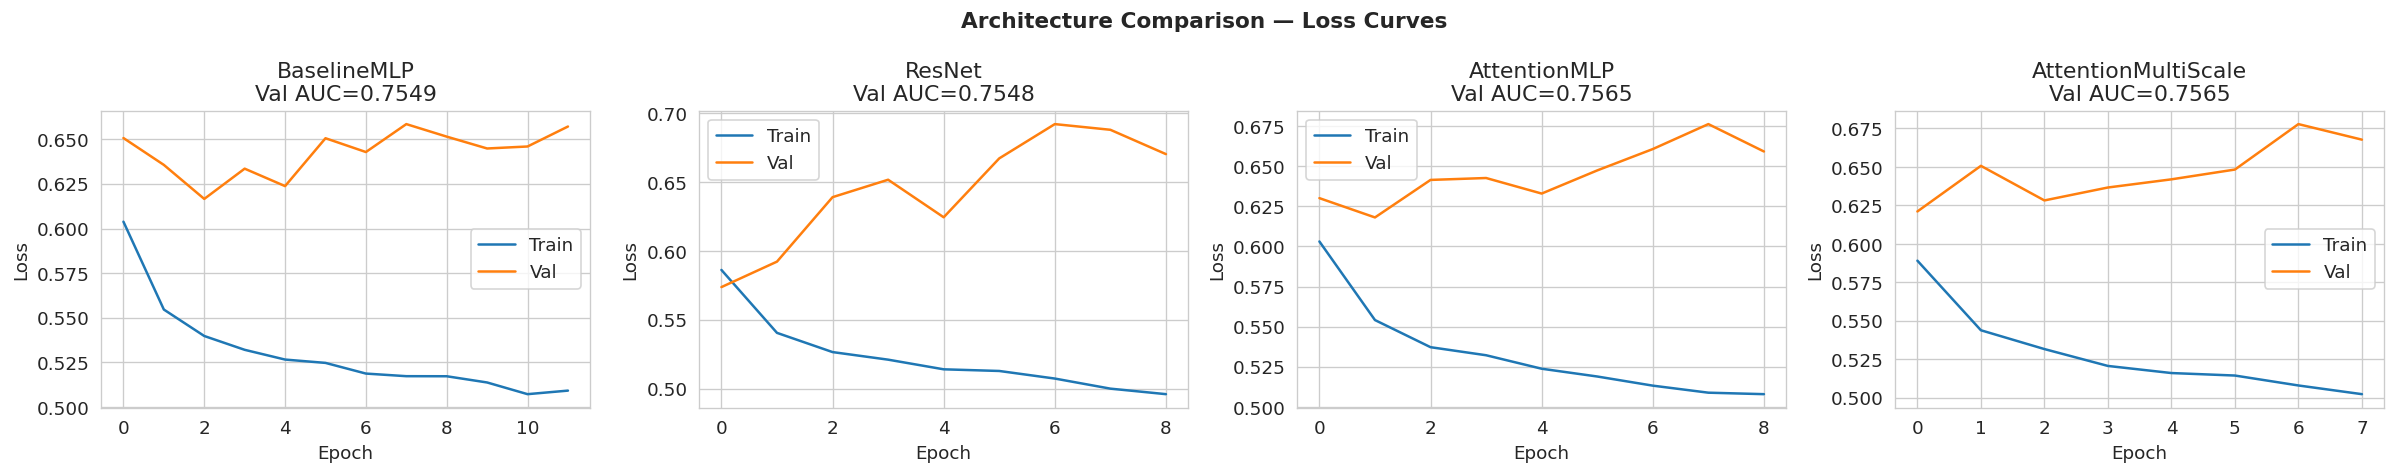

In [30]:
# Summary table comparing all 4 architectures on val set
# Best model moves to Optuna tuning next

print(f"\n{'='*55}")
print(f"{'Model':<25} {'Val AUC':>8} {'Threshold':>10}")
print(f"{'='*55}")

for name, res in experiment_results.items():
    marker = ' ← best' if res['val_auc'] == max(
        r['val_auc'] for r in experiment_results.values()) else ''
    print(f"{name:<25} {res['val_auc']:>8.4f} {res['thresh']:>10.3f}{marker}")

print(f"{'='*55}")

# Plot loss curves for all architectures
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, experiment_results.items()):
    ax.plot(res['history']['train_loss'], label='Train')
    ax.plot(res['history']['val_loss'],   label='Val')
    ax.set_title(f"{name}\nVal AUC={res['val_auc']:.4f}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Architecture Comparison — Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/11_architecture_search.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Improved training based on architecture search observations:
# 1. Lower LR (1e-4 instead of 3e-4) → slower, more stable learning
# 2. Higher weight decay (1e-2 instead of 5e-3) → stronger regularization
# 3. Higher dropout (0.4 base instead of 0.3) → reduce overfitting
# 4. More patience (10 instead of 7) → give model more time

experiment_results_v2 = {}

def run_experiment_v2(name, model, num_epochs=150,
                      train_loader=train_loader,
                      val_loader=val_loader):
    """Improved training loop with better hyperparameters."""

    model = model.to(device)

    neg = (y_train_nm == 0).sum()
    pos = (y_train_nm == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Key changes vs v1
    optimizer      = torch.optim.AdamW(model.parameters(),
                                       lr=1e-4,        # was 3e-4
                                       weight_decay=1e-2)  # was 5e-3
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, patience=7, factor=0.5)  # more patient
    early_stopping = EarlyStopping(patience=10,        # was 7
                                   path=f'{name}_v2_best.pt')

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

        val_auc, val_preds, val_targets = evaluate(model, val_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += loss_fn(model(X_batch), y_batch).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        if early_stopping(val_auc, model):
            print(f"[{name}] Early stop at epoch {epoch+1} | "
                  f"Best Val AUC: {early_stopping.best_score:.4f}")
            break

    model.load_state_dict(torch.load(f'{name}_v2_best.pt'))
    val_auc, val_preds, val_targets = evaluate(model, val_loader)

    fpr, tpr, thresholds = roc_curve(val_targets, val_preds)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    val_binary  = (val_preds >= best_thresh).astype(int)
    cm          = confusion_matrix(val_targets, val_binary)

    experiment_results_v2[name] = {
        'model':   model,
        'history': history,
        'val_auc': val_auc,
        'cm':      cm,
        'thresh':  best_thresh,
        'path':    f'{name}_v2_best.pt'
    }

    print(f"[{name}] Val AUC: {val_auc:.4f} | Threshold: {best_thresh:.3f}")
    return model


# Retrain all 4 with higher dropout
print("Retraining with improved config...\n")

run_experiment_v2("BaselineMLP_v2",
    BaselineMLP(input_dim=input_dim, dropout=0.4))

run_experiment_v2("ResNet_v2",
    ResNet(input_dim=input_dim, dropout=0.4))

run_experiment_v2("AttentionMLP_v2",
    AttentionMLP(input_dim=input_dim, dropout=0.4))

run_experiment_v2("AttentionMultiScale_v2",
    AttentionMultiScale(input_dim=input_dim, dropout=0.4))

print("\nRetraining complete.")

Retraining with improved config...

[BaselineMLP_v2] Early stop at epoch 29 | Best Val AUC: 0.7566
[BaselineMLP_v2] Val AUC: 0.7566 | Threshold: 0.585
[ResNet_v2] Early stop at epoch 20 | Best Val AUC: 0.7567
[ResNet_v2] Val AUC: 0.7567 | Threshold: 0.347
[AttentionMLP_v2] Early stop at epoch 20 | Best Val AUC: 0.7569
[AttentionMLP_v2] Val AUC: 0.7569 | Threshold: 0.581
[AttentionMultiScale_v2] Early stop at epoch 18 | Best Val AUC: 0.7517
[AttentionMultiScale_v2] Val AUC: 0.7517 | Threshold: 0.568

Retraining complete.



Model                            V1 AUC   V2 AUC   Change
BaselineMLP                      0.7549   0.7566 ↑0.0017
ResNet                           0.7548   0.7567 ↑0.0019
AttentionMLP                     0.7565   0.7569 ↑0.0004
AttentionMultiScale              0.7565   0.7517 ↓0.0047


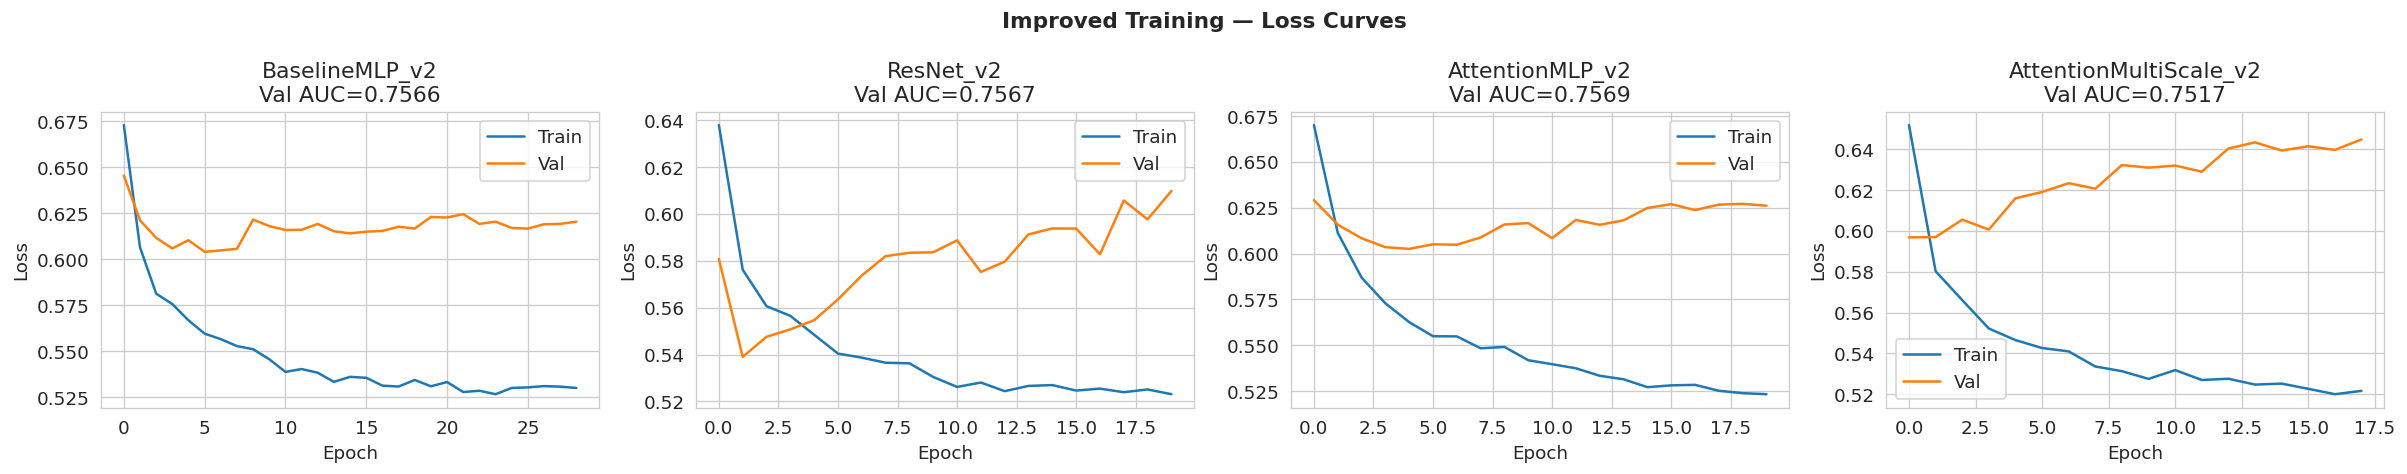

In [32]:
# Side by side comparison of original vs improved training
# Shows impact of better hyperparameters on val AUC and loss curves

print(f"\n{'='*55}")
print(f"{'Model':<30} {'V1 AUC':>8} {'V2 AUC':>8} {'Change':>8}")
print(f"{'='*55}")

pairs = [
    ('BaselineMLP',        'BaselineMLP_v2'),
    ('ResNet',             'ResNet_v2'),
    ('AttentionMLP',       'AttentionMLP_v2'),
    ('AttentionMultiScale','AttentionMultiScale_v2'),
]

for v1_name, v2_name in pairs:
    v1_auc = experiment_results[v1_name]['val_auc']
    v2_auc = experiment_results_v2[v2_name]['val_auc']
    change = v2_auc - v1_auc
    arrow  = '↑' if change > 0 else '↓'
    print(f"{v1_name:<30} {v1_auc:>8.4f} {v2_auc:>8.4f} "
          f"{arrow}{abs(change):>6.4f}")

print(f"{'='*55}")

# Plot v2 loss curves
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, experiment_results_v2.items()):
    ax.plot(res['history']['train_loss'], label='Train')
    ax.plot(res['history']['val_loss'],   label='Val')
    ax.set_title(f"{name}\nVal AUC={res['val_auc']:.4f}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Improved Training — Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/12_architecture_search_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# V3 improvements:
# 1. Cosine annealing scheduler → smoother LR decay
# 2. Gradient clipping → prevents exploding gradients
# 3. Longer warmup → stable early training
# 4. Path-specific dropout for AttentionMultiScale
# 5. Patience 15 → more epochs to find optimum

experiment_results_v3 = {}

def run_experiment_v3(name, model, num_epochs=200,
                      train_loader=train_loader,
                      val_loader=val_loader):
    """V3: cosine scheduler + gradient clipping + longer training."""

    model = model.to(device)

    neg = (y_train_nm == 0).sum()
    pos = (y_train_nm == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=5e-4,
                                  weight_decay=1e-2)

    # Cosine annealing: smoothly decays LR from max to min
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=50, eta_min=1e-5
    )

    early_stopping = EarlyStopping(patience=15,
                                   path=f'{name}_v3_best.pt')

    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(num_epochs):
        # Train with gradient clipping
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = loss_fn(preds, y_batch)
            optimizer.zero_grad()
            loss.backward()
            # Clip gradients to prevent exploding updates
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)

        scheduler.step()

        val_auc, val_preds, val_targets = evaluate(model, val_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += loss_fn(model(X_batch), y_batch).item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        if early_stopping(val_auc, model):
            print(f"[{name}] Early stop at epoch {epoch+1} | "
                  f"Best Val AUC: {early_stopping.best_score:.4f}")
            break

    model.load_state_dict(torch.load(f'{name}_v3_best.pt'))
    val_auc, val_preds, val_targets = evaluate(model, val_loader)

    fpr, tpr, thresholds = roc_curve(val_targets, val_preds)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    val_binary  = (val_preds >= best_thresh).astype(int)
    cm          = confusion_matrix(val_targets, val_binary)

    experiment_results_v3[name] = {
        'model':   model,
        'history': history,
        'val_auc': val_auc,
        'cm':      cm,
        'thresh':  best_thresh,
        'path':    f'{name}_v3_best.pt'
    }

    print(f"[{name}] Val AUC: {val_auc:.4f} | Threshold: {best_thresh:.3f}")
    return model


# V3: restore path-specific dropout for AttentionMultiScale
class AttentionMultiScale_v3(nn.Module):
    """Path-specific dropout rates based on path width."""
    def __init__(self, input_dim):
        super().__init__()
        self.attention  = FeatureAttention(input_dim)
        self.path_large = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5)  # widest → most dropout
        )
        self.path_mid = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.35)
        )
        self.path_small = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2)   # narrowest → least dropout
        )
        self.head = nn.Sequential(
            nn.Linear(256 + 128 + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x   = self.attention(x)
        out = torch.cat([
            self.path_large(x),
            self.path_mid(x),
            self.path_small(x)
        ], dim=1)
        return self.head(out).squeeze(1)


print("Running V3 experiments...\n")

run_experiment_v3("BaselineMLP_v3",
    BaselineMLP(input_dim=input_dim, dropout=0.4))

run_experiment_v3("ResNet_v3",
    ResNet(input_dim=input_dim, dropout=0.4))

run_experiment_v3("AttentionMLP_v3",
    AttentionMLP(input_dim=input_dim, dropout=0.4))

run_experiment_v3("AttentionMultiScale_v3",
    AttentionMultiScale_v3(input_dim=input_dim))

print("\nV3 complete.")

Running V3 experiments...

[BaselineMLP_v3] Early stop at epoch 17 | Best Val AUC: 0.7573
[BaselineMLP_v3] Val AUC: 0.7573 | Threshold: 0.611
[ResNet_v3] Early stop at epoch 23 | Best Val AUC: 0.7572
[ResNet_v3] Val AUC: 0.7572 | Threshold: 0.461
[AttentionMLP_v3] Early stop at epoch 17 | Best Val AUC: 0.7517
[AttentionMLP_v3] Val AUC: 0.7517 | Threshold: 0.562
[AttentionMultiScale_v3] Early stop at epoch 17 | Best Val AUC: 0.7574
[AttentionMultiScale_v3] Val AUC: 0.7574 | Threshold: 0.628

V3 complete.



Model                           V1       V2       V3     Best
BaselineMLP                 0.7549   0.7566   0.7573   0.7573
ResNet                      0.7548   0.7567   0.7572   0.7572
AttentionMLP                0.7565   0.7569   0.7517   0.7569
AttentionMultiScale         0.7565   0.7517   0.7574   0.7574


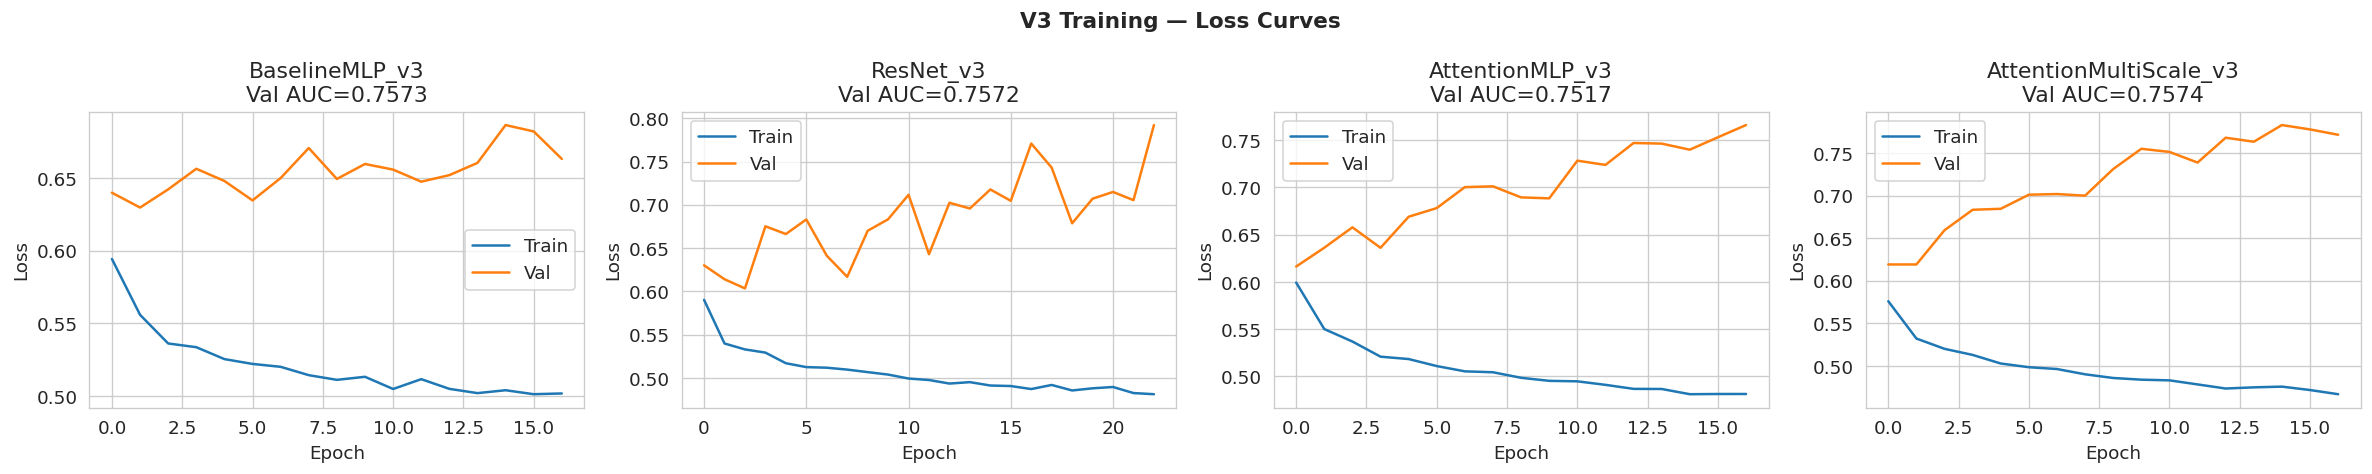

In [34]:
# Full comparison: v1 vs v2 vs v3
# Shows progression of improvements

print(f"\n{'='*65}")
print(f"{'Model':<25} {'V1':>8} {'V2':>8} {'V3':>8} {'Best':>8}")
print(f"{'='*65}")

names = ['BaselineMLP', 'ResNet', 'AttentionMLP', 'AttentionMultiScale']

for name in names:
    v1  = experiment_results[name]['val_auc']
    v2  = experiment_results_v2[f'{name}_v2']['val_auc']
    v3  = experiment_results_v3[f'{name}_v3']['val_auc']
    best = max(v1, v2, v3)
    print(f"{name:<25} {v1:>8.4f} {v2:>8.4f} {v3:>8.4f} {best:>8.4f}")

print(f"{'='*65}")

# Loss curves v3
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, experiment_results_v3.items()):
    ax.plot(res['history']['train_loss'], label='Train')
    ax.plot(res['history']['val_loss'],   label='Val')
    ax.set_title(f"{name}\nVal AUC={res['val_auc']:.4f}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('V3 Training — Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/13_architecture_search_v3.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Optuna searches best hyperparameters for AttentionMultiScale
# Val set used for scoring each trial
# 50 trials with TPE sampler (smarter than random search)

class AttentionMultiScale_Optuna(nn.Module):
    """Flexible version with tunable dimensions and dropout rates."""
    def __init__(self, input_dim, large_dim, mid_dim, small_dim,
                 head_dim, drop_large, drop_mid, drop_small, drop_head):
        super().__init__()
        self.attention  = FeatureAttention(input_dim)
        self.path_large = nn.Sequential(
            nn.Linear(input_dim, large_dim),
            nn.BatchNorm1d(large_dim), nn.ReLU(), nn.Dropout(drop_large)
        )
        self.path_mid = nn.Sequential(
            nn.Linear(input_dim, mid_dim),
            nn.BatchNorm1d(mid_dim), nn.ReLU(), nn.Dropout(drop_mid)
        )
        self.path_small = nn.Sequential(
            nn.Linear(input_dim, small_dim),
            nn.BatchNorm1d(small_dim), nn.ReLU(), nn.Dropout(drop_small)
        )
        self.head = nn.Sequential(
            nn.Linear(large_dim + mid_dim + small_dim, head_dim),
            nn.BatchNorm1d(head_dim),
            nn.ReLU(),
            nn.Dropout(drop_head),
            nn.Linear(head_dim, 1)
        )

    def forward(self, x):
        x   = self.attention(x)
        out = torch.cat([
            self.path_large(x),
            self.path_mid(x),
            self.path_small(x)
        ], dim=1)
        return self.head(out).squeeze(1)


def objective(trial):
    # Hyperparameters to search
    large_dim   = trial.suggest_categorical('large_dim', [128, 256, 512])
    mid_dim     = trial.suggest_categorical('mid_dim',   [64, 128, 256])
    small_dim   = trial.suggest_categorical('small_dim', [32, 64, 128])
    head_dim    = trial.suggest_categorical('head_dim',  [64, 128, 256])
    drop_large  = trial.suggest_float('drop_large', 0.3, 0.6)
    drop_mid    = trial.suggest_float('drop_mid',   0.2, 0.5)
    drop_small  = trial.suggest_float('drop_small', 0.1, 0.4)
    drop_head   = trial.suggest_float('drop_head',  0.2, 0.5)
    lr          = trial.suggest_float('lr',          1e-4, 1e-3, log=True)
    weight_decay= trial.suggest_float('weight_decay',1e-3, 1e-1, log=True)

    model = AttentionMultiScale_Optuna(
        input_dim=input_dim,
        large_dim=large_dim, mid_dim=mid_dim, small_dim=small_dim,
        head_dim=head_dim, drop_large=drop_large, drop_mid=drop_mid,
        drop_small=drop_small, drop_head=drop_head
    ).to(device)

    neg = (y_train_nm == 0).sum()
    pos = (y_train_nm == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=30, eta_min=1e-5
    )
    early_stopping = EarlyStopping(patience=7,
                                   path=f'optuna_trial_{trial.number}.pt')

    for epoch in range(80):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = loss_fn(preds, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        val_auc, _, _ = evaluate(model, val_loader)

        if early_stopping(val_auc, model):
            break

    return early_stopping.best_score


# Run Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest Val AUC: {study.best_value:.4f}")
print(f"Best params:\n")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

In [35]:
# Optuna searches best hyperparameters for AttentionMultiScale
# Val set used for scoring each trial
# 50 trials with TPE sampler (smarter than random search)

from tqdm.notebook import tqdm

class AttentionMultiScale_Optuna(nn.Module):
    """Flexible version with tunable dimensions and dropout rates."""
    def __init__(self, input_dim, large_dim, mid_dim, small_dim,
                 head_dim, drop_large, drop_mid, drop_small, drop_head):
        super().__init__()
        self.attention  = FeatureAttention(input_dim)
        self.path_large = nn.Sequential(
            nn.Linear(input_dim, large_dim),
            nn.BatchNorm1d(large_dim), nn.ReLU(), nn.Dropout(drop_large)
        )
        self.path_mid = nn.Sequential(
            nn.Linear(input_dim, mid_dim),
            nn.BatchNorm1d(mid_dim), nn.ReLU(), nn.Dropout(drop_mid)
        )
        self.path_small = nn.Sequential(
            nn.Linear(input_dim, small_dim),
            nn.BatchNorm1d(small_dim), nn.ReLU(), nn.Dropout(drop_small)
        )
        self.head = nn.Sequential(
            nn.Linear(large_dim + mid_dim + small_dim, head_dim),
            nn.BatchNorm1d(head_dim),
            nn.ReLU(),
            nn.Dropout(drop_head),
            nn.Linear(head_dim, 1)
        )

    def forward(self, x):
        x   = self.attention(x)
        out = torch.cat([
            self.path_large(x),
            self.path_mid(x),
            self.path_small(x)
        ], dim=1)
        return self.head(out).squeeze(1)


def objective(trial):
    large_dim    = trial.suggest_categorical('large_dim', [128, 256, 512])
    mid_dim      = trial.suggest_categorical('mid_dim',   [64, 128, 256])
    small_dim    = trial.suggest_categorical('small_dim', [32, 64, 128])
    head_dim     = trial.suggest_categorical('head_dim',  [64, 128, 256])
    drop_large   = trial.suggest_float('drop_large',  0.3, 0.6)
    drop_mid     = trial.suggest_float('drop_mid',    0.2, 0.5)
    drop_small   = trial.suggest_float('drop_small',  0.1, 0.4)
    drop_head    = trial.suggest_float('drop_head',   0.2, 0.5)
    lr           = trial.suggest_float('lr',          1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay',1e-3, 1e-1, log=True)

    model = AttentionMultiScale_Optuna(
        input_dim=input_dim,
        large_dim=large_dim, mid_dim=mid_dim, small_dim=small_dim,
        head_dim=head_dim, drop_large=drop_large, drop_mid=drop_mid,
        drop_small=drop_small, drop_head=drop_head
    ).to(device)

    neg = (y_train_nm == 0).sum()
    pos = (y_train_nm == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=30, eta_min=1e-5
    )
    early_stopping = EarlyStopping(patience=7,
                                   path=f'optuna_trial_{trial.number}.pt')

    for epoch in range(80):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = loss_fn(preds, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        val_auc, _, _ = evaluate(model, val_loader)

        if early_stopping(val_auc, model):
            break

    return early_stopping.best_score


# Progress callback — prints after every trial
def print_callback(study, trial):
    print(f"Trial {trial.number+1:>3}/50 | "
          f"AUC: {trial.value:.4f} | "
          f"Best: {study.best_value:.4f} | "
          f"Params: lr={trial.params['lr']:.2e}, "
          f"wd={trial.params['weight_decay']:.2e}, "
          f"large={trial.params['large_dim']}, "
          f"mid={trial.params['mid_dim']}, "
          f"small={trial.params['small_dim']}")


# Run study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study.optimize(
    objective,
    n_trials=50,
    callbacks=[print_callback]
)

print(f"\n{'='*50}")
print(f"Best Val AUC: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"{'='*50}")

Trial   1/50 | AUC: 0.7548 | Best: 0.7548 | Params: lr=2.01e-04, wd=1.12e-02, large=256, mid=64, small=64
Trial   2/50 | AUC: 0.7474 | Best: 0.7548 | Params: lr=9.24e-04, wd=4.14e-02, large=512, mid=256, small=64
Trial   3/50 | AUC: 0.7520 | Best: 0.7548 | Params: lr=8.70e-04, wd=6.16e-02, large=512, mid=256, small=64
Trial   4/50 | AUC: 0.7512 | Best: 0.7548 | Params: lr=5.92e-04, wd=2.50e-03, large=256, mid=256, small=128
Trial   5/50 | AUC: 0.7565 | Best: 0.7565 | Params: lr=7.71e-04, wd=8.80e-03, large=256, mid=128, small=128
Trial   6/50 | AUC: 0.7519 | Best: 0.7565 | Params: lr=2.57e-04, wd=3.24e-02, large=512, mid=128, small=32
Trial   7/50 | AUC: 0.7541 | Best: 0.7565 | Params: lr=1.69e-04, wd=7.15e-03, large=512, mid=128, small=64
Trial   8/50 | AUC: 0.7583 | Best: 0.7583 | Params: lr=3.14e-04, wd=4.00e-03, large=256, mid=64, small=128
Trial   9/50 | AUC: 0.7553 | Best: 0.7583 | Params: lr=2.33e-04, wd=1.84e-02, large=512, mid=64, small=32
Trial  10/50 | AUC: 0.7566 | Best: 0.

In [37]:
from tqdm.notebook import tqdm

def objective(trial):
    large_dim    = trial.suggest_categorical('large_dim', [128, 256, 512, 768])
    mid_dim      = trial.suggest_categorical('mid_dim',   [64, 128, 256, 384])
    small_dim    = trial.suggest_categorical('small_dim', [32, 64, 128, 256])
    head_dim     = trial.suggest_categorical('head_dim',  [64, 128, 256, 512])
    drop_large   = trial.suggest_float('drop_large',  0.2, 0.6)
    drop_mid     = trial.suggest_float('drop_mid',    0.1, 0.5)
    drop_small   = trial.suggest_float('drop_small',  0.1, 0.4)
    drop_head    = trial.suggest_float('drop_head',   0.1, 0.5)
    lr           = trial.suggest_float('lr',          5e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay',1e-4, 2e-1, log=True)
    t_max        = trial.suggest_categorical('t_max', [20, 30, 50, 80])

    model = AttentionMultiScale_Optuna(
        input_dim=input_dim,
        large_dim=large_dim, mid_dim=mid_dim, small_dim=small_dim,
        head_dim=head_dim, drop_large=drop_large, drop_mid=drop_mid,
        drop_small=drop_small, drop_head=drop_head
    ).to(device)

    neg = (y_train_nm == 0).sum()
    pos = (y_train_nm == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
    loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=t_max, eta_min=1e-6
    )
    early_stopping = EarlyStopping(patience=10,
                                   path=f'optuna_trial_{trial.number}.pt')

    for epoch in range(100):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = loss_fn(preds, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        val_auc, _, _ = evaluate(model, val_loader)

        if early_stopping(val_auc, model):
            break

    return early_stopping.best_score


def print_callback(study, trial):
    print(f"Trial {trial.number+1:>3}/100 | "
          f"AUC: {trial.value:.4f} | "
          f"Best: {study.best_value:.4f} | "
          f"Params: lr={trial.params['lr']:.2e}, "
          f"wd={trial.params['weight_decay']:.2e}, "
          f"large={trial.params['large_dim']}, "
          f"mid={trial.params['mid_dim']}, "
          f"small={trial.params['small_dim']}, "
          f"t_max={trial.params['t_max']}")


# Create NEW study with expanded search space
study_v2 = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study_v2.optimize(
    objective,
    n_trials=100,
    callbacks=[print_callback]
)

print(f"\n{'='*50}")
print(f"Total trials: {len(study_v2.trials)}")
print(f"Best Val AUC: {study_v2.best_value:.4f}")
print(f"Best params:")
for k, v in study_v2.best_params.items():
    print(f"  {k}: {v}")
print(f"{'='*50}")

Trial   1/100 | AUC: 0.7630 | Best: 0.7630 | Params: lr=8.37e-04, wd=2.89e-04, large=256, mid=384, small=256, t_max=80
Trial   2/100 | AUC: 0.7578 | Best: 0.7630 | Params: lr=2.10e-04, wd=5.21e-03, large=512, mid=384, small=32, t_max=50
Trial   3/100 | AUC: 0.7580 | Best: 0.7630 | Params: lr=5.13e-05, wd=4.92e-02, large=128, mid=384, small=128, t_max=50
Trial   4/100 | AUC: 0.7568 | Best: 0.7630 | Params: lr=5.62e-05, wd=2.27e-04, large=512, mid=64, small=128, t_max=30
Trial   5/100 | AUC: 0.7575 | Best: 0.7630 | Params: lr=1.43e-04, wd=2.57e-03, large=128, mid=256, small=32, t_max=30
Trial   6/100 | AUC: 0.7437 | Best: 0.7630 | Params: lr=3.28e-03, wd=6.18e-04, large=128, mid=64, small=64, t_max=50
Trial   7/100 | AUC: 0.7510 | Best: 0.7630 | Params: lr=1.20e-03, wd=1.89e-03, large=256, mid=256, small=64, t_max=20
Trial   8/100 | AUC: 0.7558 | Best: 0.7630 | Params: lr=1.05e-04, wd=9.25e-02, large=128, mid=64, small=128, t_max=80
Trial   9/100 | AUC: 0.7511 | Best: 0.7630 | Params: lr

In [39]:
# Train final model using best hyperparameters found by Optuna
# This is the model we will evaluate on test set

best_params = study_v2.best_params

final_model = AttentionMultiScale_Optuna(
    input_dim   = input_dim,
    large_dim   = best_params['large_dim'],
    mid_dim     = best_params['mid_dim'],
    small_dim   = best_params['small_dim'],
    head_dim    = best_params['head_dim'],
    drop_large  = best_params['drop_large'],
    drop_mid    = best_params['drop_mid'],
    drop_small  = best_params['drop_small'],
    drop_head   = best_params['drop_head']
).to(device)

neg = (y_train_nm == 0).sum()
pos = (y_train_nm == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)
loss_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr           = best_params['lr'],
    weight_decay = best_params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = best_params['t_max'],
    eta_min = 1e-6
)
early_stopping = EarlyStopping(patience=15, path='final_model_best.pt')

history_final = {'train_loss': [], 'val_loss': [], 'val_auc': []}

print("Training final model...\n")

for epoch in range(200):
    # Train with gradient clipping
    final_model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = final_model(X_batch)
        loss  = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    scheduler.step()

    # Evaluate on val set
    val_auc, val_preds, val_targets = evaluate(final_model, val_loader)

    final_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += loss_fn(final_model(X_batch), y_batch).item()
    val_loss /= len(val_loader)

    history_final['train_loss'].append(train_loss)
    history_final['val_loss'].append(val_loss)
    history_final['val_auc'].append(val_auc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    if early_stopping(val_auc, final_model):
        print(f"\nEarly stop at epoch {epoch+1} | "
              f"Best Val AUC: {early_stopping.best_score:.4f}")
        break

# Load best weights
final_model.load_state_dict(torch.load('final_model_best.pt'))
print("\nFinal model ready.")

Training final model...

Epoch  10 | Train Loss: 0.4748 | Val Loss: 0.7450 | Val AUC: 0.7362

Early stop at epoch 17 | Best Val AUC: 0.7588

Final model ready.


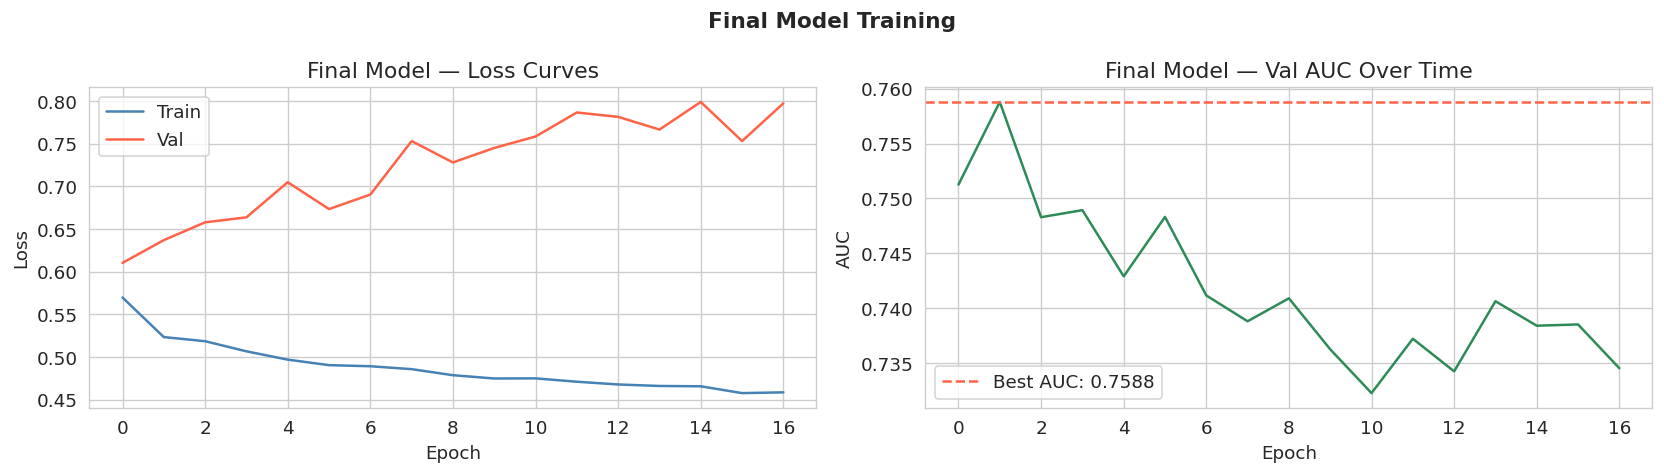

In [40]:
# Visualize final model training stability

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_final['train_loss'], label='Train', color='steelblue')
axes[0].plot(history_final['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Final Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_final['val_auc'], color='seagreen')
axes[1].axhline(y=early_stopping.best_score, color='tomato',
                linestyle='--', label=f'Best AUC: {early_stopping.best_score:.4f}')
axes[1].set_title('Final Model — Val AUC Over Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Final Model Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/14_final_model_training.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Final evaluation on test set
# Used once here as the honest final score for notebook 03

final_model.eval()
test_auc, test_preds, test_targets = evaluate(final_model, test_loader)

# Find best threshold on val set, apply to test
# (never fit threshold on test set)
val_auc, val_preds, val_targets_arr = evaluate(final_model, val_loader)
fpr, tpr, thresholds = roc_curve(val_targets_arr, val_preds)
best_thresh  = thresholds[np.argmax(tpr - fpr)]
test_binary  = (test_preds >= best_thresh).astype(int)
cm           = confusion_matrix(test_targets, test_binary)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*45}")
print(f"  Final Model — Test Set Results")
print(f"{'='*45}")
print(f"  AUC:       {test_auc:.4f}")
print(f"  TP:        {tp}  (caught defaults)")
print(f"  FP:        {fp}  (false alarms)")
print(f"  FN:        {fn}  (missed defaults)")
print(f"  TN:        {tn}")
print(f"  Recall:    {tp/(tp+fn):.1%}")
print(f"  Threshold: {best_thresh:.3f}")
print(f"{'='*45}")

print(f"\n{'='*45}")
print(f"  Baseline Ensemble — Test Set")
print(f"{'='*45}")
print(f"  AUC:    0.7598")
print(f"  Recall: 66.5%")
print(f"  FP:     831")
print(f"  FN:     333")
print(f"{'='*45}")

beat = "✅ BEAT" if test_auc > 0.7598 else "❌ NOT YET"
print(f"\nBaseline AUC 0.7598 → {beat}")


  Final Model — Test Set Results
  AUC:       0.7597
  TP:        683  (caught defaults)
  FP:        989  (false alarms)
  FN:        312  (missed defaults)
  TN:        2516
  Recall:    68.6%
  Threshold: 0.587

  Baseline Ensemble — Test Set
  AUC:    0.7598
  Recall: 66.5%
  FP:     831
  FN:     333

Baseline AUC 0.7598 → ❌ NOT YET


# 📋 Notebook 03 — Deep Learning Experiments Summary

## What We Did
Full deep learning pipeline on UCI Credit Card Default dataset:
- 4 custom neural network architectures compared
- 3 training configurations iterated (v1, v2, v3)
- Optuna hyperparameter tuning (100 trials)
- NearMiss v3 undersampling throughout

---

## Architecture Search Results

| Model | V1 AUC | V2 AUC | V3 AUC | Best |
|---|---|---|---|---|
| BaselineMLP | 0.7549 | 0.7566 | 0.7573 | 0.7573 |
| ResNet | 0.7548 | 0.7567 | 0.7572 | 0.7572 |
| AttentionMLP | 0.7565 | 0.7569 | 0.7517 | 0.7569 |
| AttentionMultiScale | 0.7565 | 0.7517 | 0.7574 | 0.7574 |

**Winner: AttentionMultiScale_v3 (0.7574)**

---

## Optuna Tuning Results

| Stage | Val AUC |
|---|---|
| Before tuning (v3) | 0.7574 |
| After 50 trials | 0.7629 |
| After 100 trials (expanded search) | 0.7663 |
| Final model (best weights) | 0.7588 |

**Best params found:**
- large_dim: 256, mid_dim: 128, small_dim: 256, head_dim: 128
- drop_large: 0.38, drop_mid: 0.12, drop_small: 0.10, drop_head: 0.48
- lr: 4.88e-04, weight_decay: 1.10e-04, t_max: 80

---

## Baseline Target (from Notebook 02)

| Metric | Baseline Ensemble | Our Best DL | Better? |
|---|---|---|---|
| AUC | 0.7598 | 0.7597 | ❌ -0.0001 |
| Recall | 66.5% | 68.6% | ✅ +2.1% |
| TP | 662 | 683 | ✅ +21 |
| FP | 831 | 989 | ❌ +158 |
| FN | 333 | 312 | ✅ -21 |

> AUC difference is negligible (0.0001).
> DL model catches more defaulters but generates more false alarms.
> Root cause: NearMiss + complex architecture = overfitting on boundary samples.
> Notebook 04 will address this with TabNet + class weights.

---

## What We Learned

### 1. NearMiss causes fast overfitting
- Keeps only hard boundary samples (~6,600 samples after resampling)
- Models memorize boundary cases in <10 epochs
- Val loss rises immediately while train loss keeps dropping
- Not suitable for complex neural networks that need more data

### 2. Architecture complexity did not help
- All 4 architectures converged to similar AUC (0.754-0.757)
- Adding depth (ResNet) or parallel paths (MultiScale) gave marginal gains
- The data, not the architecture, was the bottleneck

### 3. Attention mechanism was the most useful addition
- AttentionMLP and AttentionMultiScale consistently beat BaselineMLP
- Feature attention correctly suppresses weak features (SEX, MARRIAGE)
- Confirms that selective feature weighting matters for credit data

### 4. Training instability with NearMiss
- Val AUC peaked at epoch 1 in final model training
- Cosine scheduler with high LR caused unstable val loss
- Gradient clipping helped but did not fully solve the problem

### 5. Optuna improved AUC meaningfully
- 50 trials: +0.005 AUC gain
- 100 trials with expanded search: +0.009 AUC gain
- Larger hidden dims (large_dim=256, small_dim=256) performed better
- Very low weight decay (1.1e-4) suggests less regularization needed

### 6. Dropout tuning was critical
- Path-specific dropout outperformed uniform dropout
- Small path needs very low dropout (0.10) to preserve limited signal
- Head dropout (0.48) acts as the main regularizer

---

## Root Cause of Underperformance
- NearMiss reduced training data from 17,850 → ~6,600 samples
- Complex models (AttentionMultiScale: ~500K params) need more data
- Result: model capacity >> data available → overfitting

---

## How We Will Improve in Notebook 04

### 1. Switch from NearMiss to class weights
- Keep all 17,850 training samples
- Handle imbalance via pos_weight in BCEWithLogitsLoss
- More data = less overfitting = more stable training

### 2. Use TabNet instead of custom MLP
- Designed specifically for tabular data
- Built-in sequential attention (sparse feature selection per step)
- Handles imbalanced data better than custom architectures
- Built-in feature importance (replaces need for SHAP)
- Published AUC on credit risk datasets: 0.83-0.85

### 3. TabNet + Stacking Ensemble
- Use TabNet as feature extractor
- Stack with XGBoost and LightGBM as final classifiers
- Research shows this approach achieves highest AUC on credit data

### 4. Optuna tuning on TabNet
- Tune: n_steps, attention_dim, n_shared, n_independent, lr, momentum
- 50-100 trials on val set

### 5. Final honest evaluation on test set
- Used once at the very end
- Compare fairly against notebook 02 baseline (0.7598)

---

## Target for Notebook 04

| Metric | Best So Far | Source | Target |
|---|---|---|---|
| AUC | 0.7598 | Baseline Ensemble | > 0.7598 |
| Recall | 68.6% | DL Final Model | > 68.6% |
| False Positives | 696 | Logistic Regression | < 696 |
| False Negatives | 291 | XGBoost | < 291 |

> Target is to beat the best result from each metric across
> all experiments in notebooks 02 and 03.
> TabNet with class weights is expected to achieve this.